In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": False,     
    "font.family": "serif",
    "mathtext.fontset": "cm", 
    #"font.size": 12,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2
})



In [2]:
import os

print(os.getcwd())

c:\Users\Julian Samuel\Documents\GitHub\Protuberance-Optimization\Codes


In [3]:
route_cam8 = "C:/Users/Julian Samuel/Documents/GitHub/Protuberance-Optimization/Datos_sim cam 8"

files = {}

for file in os.listdir(route_cam8):
    if file.endswith(".csv"):
        data = pd.read_csv(os.path.join(route_cam8, file), skiprows=4)
        files[file] = data
print(files.keys())

print(files["cp_1000_z.csv"].head())

dict_keys(['cp1000_y.csv', 'cp_1000.csv', 'cp_1000_z.csv', 'cp_cam_y.csv', 'Cp_cross.csv', 'cp_curve_cam.csv'])
    Z [ m ]  Pressure Coefficient
0  0.183960             -0.006008
1  0.187231             -0.003796
2  0.189652             -0.002870
3  0.190792             -0.004130
4  0.190811             -0.004169


74 74


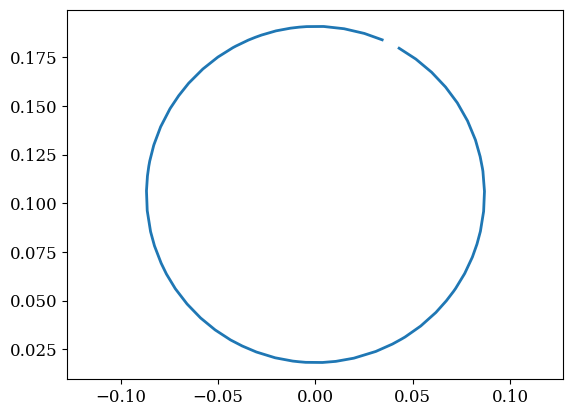

In [4]:
z = files["cp_1000_z.csv"]["Z [ m ]"]
y = files["cp1000_y.csv"]["Y [ m ]"]
print(len(z),len(y))
plt.figure()
plt.plot(y, z)
plt.axis('equal')
plt.show()

In [5]:
route_opt = "C:/Users/Julian Samuel/Documents/GitHub/Protuberance-Optimization/datos sim optim"

files_optim = {}

for file in os.listdir(route_opt):
    if file.endswith(".csv"):
        data = pd.read_csv(os.path.join(route_opt, file), skiprows=4)
        files_optim[file] = data
print(files_optim.keys())

print(files_optim["cp1000_z.csv"].head())

dict_keys(['cp1000_z.csv', 'cp_1000_y.csv', 'cp_cam.csv', 'cp_crossaxial.csv'])
    Z [ m ]  Pressure Coefficient
0  0.174943             -0.017011
1  0.180077             -0.009255
2  0.183918             -0.006062
3  0.187053             -0.004263
4  0.189343             -0.003539


In [6]:
files_optim["cp_crossaxial.csv"]

,X [ m ],Pressure Coefficient
0,-9.03546587e-02,-6.11170530e-01
1,-9.02806520e-02,-6.42461777e-01
2,-9.02014002e-02,-5.95556378e-01
3,-9.00873840e-02,-5.05564034e-01
4,-9.00015905e-02,-4.49049234e-01
...,...,...
1103,-1.10226560e+00,-8.95005167e-01
1104,-1.10085225e+00,-6.22539043e-01
1105,-1.09920359e+00,-5.19160211e-01
1106,-1.09741461e+00,-5.65254152e-01


In [7]:
z_optim = files_optim["cp1000_z.csv"]["Z [ m ]"]
y_optim = files_optim["cp_1000_y.csv"]["Y [ m ]"]
print(len(z),len(y))


74 74


In [8]:
route_cp_solo = "C:/Users/Julian Samuel/Documents/GitHub/Protuberance-Optimization/cp_solo.csv"
route_cp_rail = "C:/Users/Julian Samuel/Documents/GitHub/Protuberance-Optimization/cp_rail.csv"

data_cp_solo = pd.read_csv(route_cp_solo, skiprows=4)
data_cp_rail = pd.read_csv(route_cp_rail, skiprows=4)

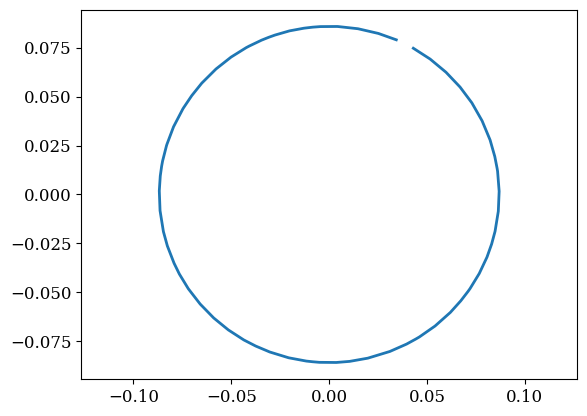

In [9]:
def rot_marix(pitch, roll):
    M_pitch = np.array([
        
        [np.cos(pitch), 0, -np.sin(pitch)],
        [0, 1, 0],
        [np.sin(pitch), 0, np.cos(pitch)]
        
        ])

    M_roll = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll), np.cos(roll)]
        ])
    return M_pitch @ M_roll



x = np.ones(len(z))*np.cos(np.radians(6)) 
r = list(zip(x, y, z))
r_shaped = r @ rot_marix(np.radians(6), np.radians(0))

r_optim = list(zip(x, y_optim, z_optim))
r_optim_shaped = r_optim @ rot_marix(np.radians(6), np.radians(0))


plt.figure()
plt.plot(r_shaped[:, 1], r_shaped[:, 2])
plt.axis('equal')
plt.show()


In [10]:
ref = np.array([0, min(r_shaped[:, 2])])   # (y,z)

yz = r_shaped[:, 1:3]
cross = ref[0]*yz[:, 1] - ref[1]*yz[:, 0]
dot = ref[0]*yz[:, 0] + ref[1]*yz[:, 1]

theta = np.degrees(np.arctan2(cross, dot))

theta = np.mod(theta, 180)
theta

array([156.54470701, 163.00637031, 170.14302986, 177.0551147 ,
       177.3635128 ,   3.01850653,   5.57392863,   8.61425388,
        13.59636442,  13.67567907,  18.77701084,  21.11124198,
        23.63484861,  28.35374282,  29.49495612,  35.53699858,
        42.06505251,  48.87082744,  54.30333278,  59.30619859,
        59.7165041 ,  66.51185731,  66.5251533 ,  72.86863883,
        73.38476471,  78.64720048,  80.43939383,  83.75702521,
        88.7864703 ,  95.46954389, 102.63812905, 107.63039156,
       113.90102054, 117.9869901 , 123.80628199, 130.33365789,
       136.92301107, 143.33616429, 149.55489066, 149.71028943,
       154.12089891, 159.34628877, 166.06895175, 172.19688524,
       174.35075512, 176.65061486,   2.40431937,   7.00226404,
        13.2661288 ,  21.13349537,  27.33711406,  30.94491032,
        32.32683857,  38.81561437,  45.75940282,  51.05481567,
        55.02235921,  56.25483592,  62.20960457,  68.34343544,
        73.02350896,  77.46722487,  84.29678635,  91.05

In [11]:
ref = np.array([0, max(r_optim_shaped[:, 2])])   # (y,z)

yz_optim = r_optim_shaped[:, 1:3]
cross_o = ref[0]*yz_optim[:, 1] - ref[1]*yz_optim[:, 0]
dot_o = ref[0]*yz_optim[:, 0] + ref[1]*yz_optim[:, 1]

theta_o = np.degrees(np.arctan2(cross_o, dot_o))

theta_o = np.mod(theta_o, 180)
theta_o

array([144.28478253, 150.64240679, 156.48289776, 162.55615077,
       168.91102569, 174.85668111, 176.68964139,   0.28274594,
         5.20311806,   6.07239858,  12.78485303,  20.26842635,
        27.80864724,  33.4784426 ,  38.78072286,  46.16557787,
        50.96450724,  57.59561754,  64.80015618,  67.31545305,
        70.36002568,  75.56574212,  77.39370271,  82.3093712 ,
        83.18110657,  89.42701457,  96.32756118, 103.19567487,
       108.9756001 , 111.73583832, 114.54790492, 120.24682397,
       126.8431961 , 131.07740432, 138.486706  , 146.10746011,
       153.77952762, 161.30677211, 166.7687358 , 174.17884487,
       178.25993188, 179.49311851,   3.21817434,   9.2347299 ,
        14.68452514,  20.41526729,  27.02843294,  31.19496618,
        37.99846306,  44.57471664,  51.95114647,  56.24240583,
        62.89378399,  69.93293393,  70.13575632,  75.75590051,
        78.70221768,  80.98071393,  86.88908604,  93.5885718 ,
       100.23236936, 106.14331614, 106.48380915, 110.99

In [12]:
data_shaped = pd.DataFrame({
    "theta": theta,
    "Cp": files["cp_1000_z.csv"]["Pressure Coefficient"],
    "y": r_shaped[:, 1],
    "z": r_shaped[:, 2]
})
data_shaped

data_optim_shaped = pd.DataFrame({
    "theta": theta_o,
    "Cp": files_optim["cp1000_z.csv"]["Pressure Coefficient"],
    "y": r_optim_shaped[:, 1],
    "z": r_optim_shaped[:, 2]
})



In [13]:
# Camera 8
starboard = data_shaped[y >= 0]
port = data_shaped[y < 0]
starboard = starboard.sort_values("theta")
port = port.sort_values("theta")
port["theta"] = np.abs(port["theta"] -180)

# optim

starboard_optim = data_optim_shaped[y_optim >= 0]
port_optim = data_optim_shaped[y_optim < 0]
starboard_optim = starboard_optim.sort_values("theta")
port_optim = port_optim.sort_values("theta")
port_optim["theta"] = np.abs(port_optim["theta"] -180)

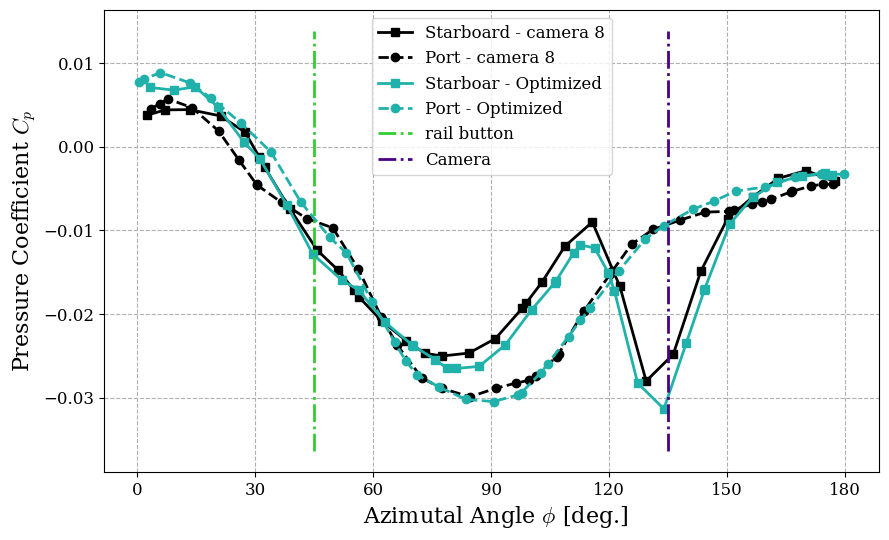

In [31]:
plt.figure(figsize=(10, 6))
#plt.scatter(theta_pos["theta"], theta_pos["Cp"], label="Cp cam 8 upper")
#plt.scatter(theta_neg["theta"], theta_neg["Cp"], label="Cp cam 8 lower")
plt.plot(starboard["theta"], starboard["Cp"], marker = "s", label="Starboard - camera 8", color = "k")
plt.plot(port["theta"], port["Cp"], marker = "o", label="Port - camera 8", color = "k", linestyle = "--")
plt.plot(starboard_optim["theta"], starboard_optim["Cp"], marker = "s", label = "Starboar - Optimized", color = "lightseagreen")
plt.plot(port_optim["theta"], port_optim["Cp"], marker = "o", label = "Port - Optimized", linestyle = "--", color= "lightseagreen")

plt.plot([45, 45], [data_optim_shaped["Cp"].min() - 0.005, data_optim_shaped["Cp"].max() + 0.005], linestyle = "-.", label = "rail button", color = "limegreen")
plt.plot([135, 135], [data_optim_shaped["Cp"].min() - 0.005, data_optim_shaped["Cp"].max() + 0.005], linestyle = "-.", label = "Camera", color = "indigo")
plt.xlabel(" Azimutal Angle $\\phi$ [deg.]")
plt.ylabel("Pressure Coefficient $C_p$")
#plt.title(" vs")
plt.xticks(np.arange(0,181, 30))
plt.grid(linestyle='--')
plt.legend()
plt.show()

In [15]:
x_solo = np.ones(len(data_cp_solo["Z [ m ]"]))*np.cos(np.radians(6)) 
r_solo = list(zip(x_solo, y, data_cp_solo["Z [ m ]"]))
r_shaped_solo = r_solo @ rot_marix(np.radians(6), np.radians(0))

In [16]:
x_rail = np.ones(len(data_cp_rail["Z [ m ]"]))*np.cos(np.radians(6)) 
r_rail = list(zip(x_rail, y, data_cp_rail["Z [ m ]"]))
r_shaped_rail = r_rail @ rot_marix(np.radians(6), np.radians(0))

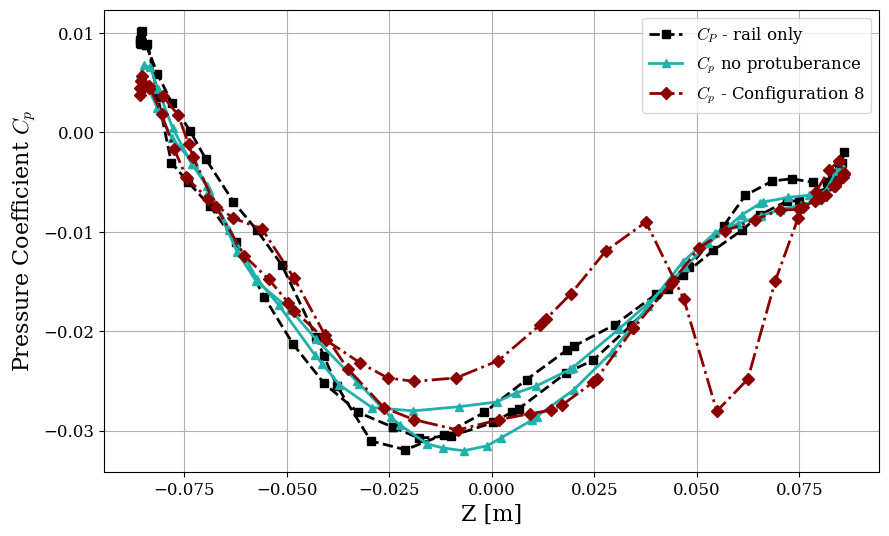

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(r_shaped_rail[:,2], data_cp_rail["Pressure Coefficient"],
        label = "$C_P$ - rail only", color = "k", marker = "s", linestyle = "--")
plt.plot(r_shaped_solo[:,2] , data_cp_solo["Pressure Coefficient"], 
         label = "$C_p$ no protuberance", color = "lightseagreen", linestyle = "-", marker = "^")
plt.plot(r_shaped[:,2], data_shaped["Cp"], 
        color = "darkred", linestyle = "-.", marker = "D", label = "$C_p$ - Configuration 8")
#plt.plot(r_optim_shaped[:,2], data_optim_shaped["Cp"],
#        color = "darkred", linestyle = ":", marker = "<", label = "optim")
plt.plot()
plt.grid()
plt.legend()
plt.xlabel("Z [m]")
plt.ylabel("Pressure Coefficient $C_p$")
plt.show()

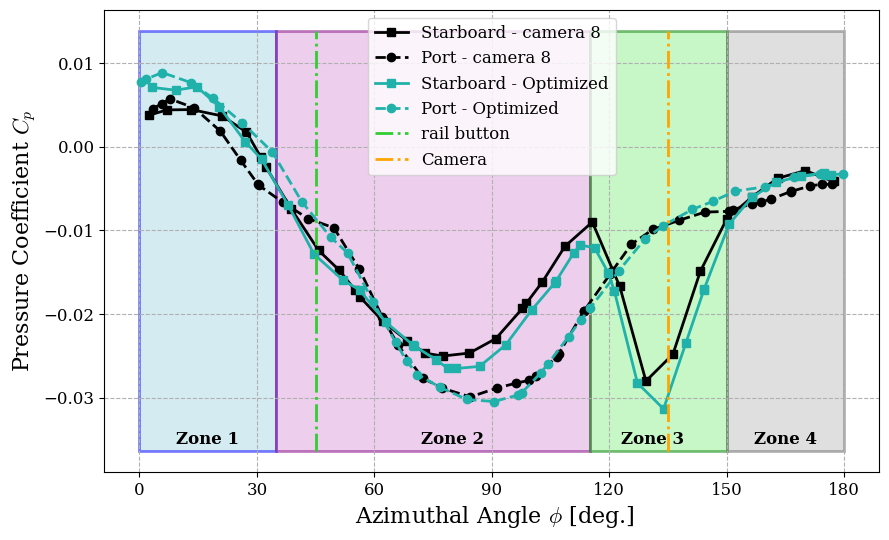

In [59]:
import matplotlib.patches as patches
fig, ax  = plt.subplots(figsize = (10,6))
#.figure(figsize=(10, 6))
#plt.scatter(theta_pos["theta"], theta_pos["Cp"], label="Cp cam 8 upper")
#plt.scatter(theta_neg["theta"], theta_neg["Cp"], label="Cp cam 8 lower")
ax.plot(starboard["theta"], starboard["Cp"], marker = "s", label="Starboard - camera 8", color = "k")
ax.plot(port["theta"], port["Cp"], marker = "o", label="Port - camera 8", color = "k", linestyle = "--")
ax.plot(starboard_optim["theta"], starboard_optim["Cp"], marker = "s", label = "Starboard - Optimized", color = "lightseagreen")
ax.plot(port_optim["theta"], port_optim["Cp"], marker = "o", label = "Port - Optimized", linestyle = "--", color= "lightseagreen")

ax.plot([45, 45], [data_optim_shaped["Cp"].min() - 0.005, data_optim_shaped["Cp"].max() + 0.005], linestyle = "-.", label = "rail button", color = "limegreen")
ax.plot([135, 135], [data_optim_shaped["Cp"].min() - 0.005, data_optim_shaped["Cp"].max() + 0.005], linestyle = "-.", label = "Camera", color = "orange")


cuadrado1 = patches.Rectangle(
    (0, data_optim_shaped["Cp"].min() - 0.005),  # (x, y)
    35,         # ancho (width)
    data_optim_shaped["Cp"].max() + 0.005 - data_optim_shaped["Cp"].min()+0.005,         # alto (height)
    linewidth=2, # grosor del borde
    edgecolor='blue', # color del borde
    facecolor='lightblue', # color de relleno
    alpha = 0.5
)



cuadrado2 = patches.Rectangle(
    (35, data_optim_shaped["Cp"].min() - 0.005),  # (x, y)
    115 - 35,         # ancho (width)
    data_optim_shaped["Cp"].max() + 0.005 - data_optim_shaped["Cp"].min()+0.005,         # alto (height)
    linewidth=2, # grosor del borde
    edgecolor='purple', # color del borde
    facecolor='plum', # color de relleno
    alpha = 0.5
)


cuadrado3 = patches.Rectangle(
    (115, data_optim_shaped["Cp"].min() - 0.005),  # (x, y)
    150 -115,         # ancho (width)
    data_optim_shaped["Cp"].max() + 0.005 - data_optim_shaped["Cp"].min()+0.005,         # alto (height)
    linewidth=2, # grosor del borde
    edgecolor='green', # color del borde
    facecolor='lightgreen', # color de relleno
    alpha = 0.5
)

cuadrado4 = patches.Rectangle(
    (150, data_optim_shaped["Cp"].min() - 0.005),  # (x, y)
    30,         # ancho (width)
    data_optim_shaped["Cp"].max() + 0.005 - data_optim_shaped["Cp"].min()+0.005,         # alto (height)
    linewidth=2, # grosor del borde
    edgecolor='dimgrey', # color del borde
    facecolor='silver', # color de relleno
    alpha = 0.5
)

# 3. Añadir el parche (patch) a los ejes
ax.add_patch(cuadrado1)
ax.add_patch(cuadrado2)
ax.add_patch(cuadrado3)
ax.add_patch(cuadrado4)

ax.text(
    35/2, -0.035,           # Coordenadas (x, y) donde irá el texto
    'Zone 1',        # El texto que quieres mostrar
    fontsize=12,          # Tamaño de la fuente
    color='k',     # Color del texto
    ha='center',          # Alineación horizontal ('center', 'left', 'right')
    va='center',          # Alineación vertical ('center', 'top', 'bottom')
    fontweight='bold'     # Grosor de la fuente (opcional)
)

ax.text(
    80, -0.035,           # Coordenadas (x, y) donde irá el texto
    'Zone 2',        # El texto que quieres mostrar
    fontsize=12,          # Tamaño de la fuente
    color='k',     # Color del texto
    ha='center',          # Alineación horizontal ('center', 'left', 'right')
    va='center',          # Alineación vertical ('center', 'top', 'bottom')
    fontweight='bold'     # Grosor de la fuente (opcional)
)

ax.text(
    131, -0.035,           # Coordenadas (x, y) donde irá el texto
    'Zone 3',        # El texto que quieres mostrar
    fontsize=12,          # Tamaño de la fuente
    color='k',     # Color del texto
    ha='center',          # Alineación horizontal ('center', 'left', 'right')
    va='center',          # Alineación vertical ('center', 'top', 'bottom')
    fontweight='bold'     # Grosor de la fuente (opcional)
)

ax.text(
    165, -0.035,           # Coordenadas (x, y) donde irá el texto
    'Zone 4',        # El texto que quieres mostrar
    fontsize=12,          # Tamaño de la fuente
    color='k',     # Color del texto
    ha='center',          # Alineación horizontal ('center', 'left', 'right')
    va='center',          # Alineación vertical ('center', 'top', 'bottom')
    fontweight='bold'     # Grosor de la fuente (opcional)
)

plt.xlabel(" Azimuthal Angle $\\phi$ [deg.]")
plt.ylabel("Pressure Coefficient $C_p$")
#plt.title(" vs")
plt.xticks(np.arange(0,181, 30))
plt.grid(linestyle='--')
plt.legend()
plt.show()


# x

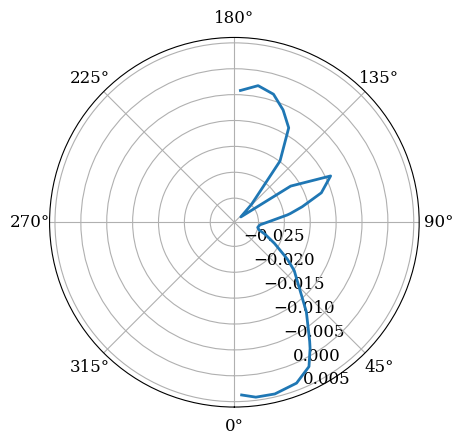

In [41]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(starboard["theta"]*np.pi/180, starboard["Cp"])
ax.set_theta_zero_location('S')


plt.show()

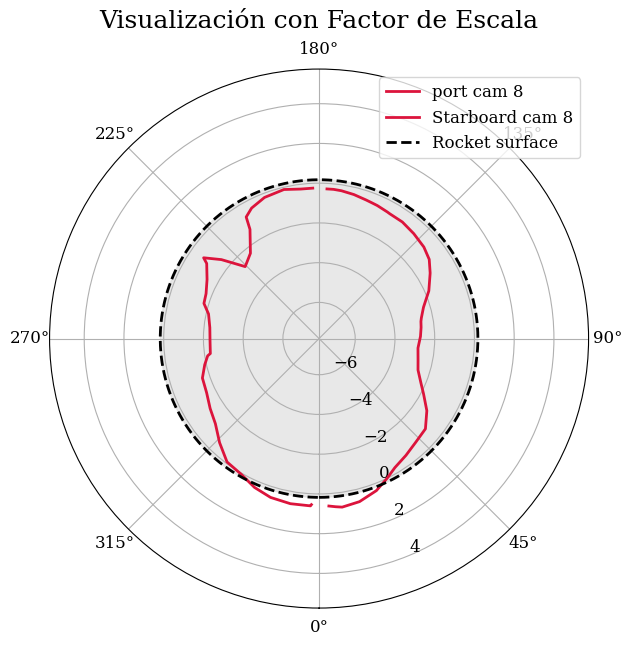

In [59]:

# Datos de prueba con magnitudes muy diferentes
theta = port["theta"]*np.pi/180
R_cilindro = 0.174  # Cilindro enorme
cp_lista = port["Cp"]

cp_2 = starboard["Cp"]
tetha_2 = starboard["theta"][::-1] * np.pi/180 + np.pi
# --- TRUCO DE ESCALA ---
# Multiplicamos el Cp por un factor para que "salte a la vista" (ej. factor de 10)
factor_escala = 100.0  
r_grafico = R_cilindro + (cp_lista * factor_escala)
r_grafico_2 = R_cilindro + (cp_2 * factor_escala)

theta_cyl = np.linspace(0, 2 * np.pi, 360)
# ------------------------

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))

# Graficar Cp amplificado y el contorno real
ax.plot(theta, r_grafico, color='crimson', linewidth=2, label=f'port cam 8')
ax.plot(tetha_2, r_grafico_2, color = "crimson", linewidth = 2, label = "Starboard cam 8", )
ax.plot(theta_cyl, np.ones_like(theta_cyl) * R_cilindro, color='black', linestyle='--', linewidth=2, label='Rocket surface')
ax.fill(theta_cyl, np.ones_like(theta_cyl) * R_cilindro, color='lightgray', alpha=0.5)

# Configurar límites para hacer un "zoom" estricto a la zona de interés
# Evitamos que se muestre todo el espacio vacío desde el centro (0) hasta el radio 100
limite_inferior = R_cilindro + (np.min(cp_lista) * factor_escala) - 5
limite_superior = R_cilindro + (np.max(cp_lista) * factor_escala) + 5
ax.set_rlim(limite_inferior, limite_superior)

ax.set_theta_zero_location('S')
ax.set_title("Visualización con Factor de Escala", va='bottom')
ax.legend()
plt.show()


In [57]:
Area_cam_8_st = np.trapezoid(starboard["theta"], starboard["Cp"])
Area_cam_8_p = np.trapezoid(port["theta"], port["Cp"])

Delta_A_cam8 = Area_cam_8_st - Area_cam_8_p


# Optimum case
Area_optim_st = np.trapezoid(starboard_optim["theta"], starboard_optim["Cp"])
Area_optim_p = np.trapezoid(port_optim["theta"], port_optim["Cp"])

Delta_A_optim = Area_optim_st - Area_optim_p

print(f"Cp distribution area difference between Starboard and port sides for config 8:{round(Delta_A_cam8,3)}")
print(f"Cp distribution area difference between Starboard and port sides for optimized case:{round(Delta_A_optim,3)}")

Cp distribution area difference between Starboard and port sides for config 8:2.776
Cp distribution area difference between Starboard and port sides for optimized case:3.12


In [58]:
files["Cp_cross.csv"].info()

<class 'pandas.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   X [ m ]               1104 non-null   str  
 1   Pressure Coefficient  1104 non-null   str  
dtypes: str(2)
memory usage: 17.4 KB


In [ ]:
cp_cross_cam8 = files["Cp_cross.csv"]
cp_cross_optim = files_optim["cp_crossaxial.csv"]
idx_8 = cp_cross_cam8[cp_cross_cam8["X [ m ]"] == "undef"].index.tolist()

idx_opt = cp_cross_optim[cp_cross_optim["X [ m ]"] == "undef"].index.tolist()


 
cp_c_8_1 = cp_cross_cam8.loc[:idx_8[0] - 1]
cp_c_8_2 = cp_cross_cam8.loc[idx_8[0]+1: idx_8[1] -1]
cp_c_8_3 = cp_cross_cam8.loc[idx_8[1]+1: idx_8[2] -1]
cp_c_8_4 = cp_cross_cam8.loc[idx_8[2]+1:]

cp_8 = {"cp_c_8_1" :cp_c_8_1 , 
        "cp_c_8_2" = cp_c_8_2,
        "cp_c_8_3", cp_c_8_4}




TypeError: unhashable type: 'DataFrame'

In [83]:
cp_c_8.info()

<class 'pandas.DataFrame'>
RangeIndex: 1101 entries, 0 to 1100
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   X [ m ]               1101 non-null   str  
 1   Pressure Coefficient  1101 non-null   str  
dtypes: str(2)
memory usage: 17.3 KB


In [84]:

cp_c_8["X [ m ]"] = pd.to_numeric(cp_c_8["X [ m ]"])
cp_c_8["Pressure Coefficient"] = pd.to_numeric(cp_c_8["Pressure Coefficient"])

#files_optim["cp_crossaxial.csv"]["X [ m ]"] = pd.to_numeric(files_optim["cp_crossaxial.csv"]["X [ m ]"])
#files_optim["cp_crossaxial.csv"]["Pressure Coefficient"] = pd.to_numeric(files_optim["cp_crossaxial.csv"]["Pressure Coefficient"])


In [86]:

plt.figure(figsize = (12, 6))
plt.plot(cp_c_8_1["X [ m ]"] + 3.240, cp_c_8_1["Pressure Coefficient"], label = "Camera 8 Cp")
#plt.scatter(cp_cross_optim["X [ m ]"] + 3.240, cp_cross_optim["Pressure Coefficient"], label = "Optimized Cp", s = 0.5)
plt.legend()
plt.grid()
plt.show()


TypeError: can only concatenate str (not "float") to str

<Figure size 1200x600 with 0 Axes>